# Project 8 — VC Pitch Intake & Triage

## Quality vs cost benchmark for prompt engineering

Ce notebook est le **livrable technique principal** du projet. Il compare un modèle local (`deepseek-r1:8b`) et un modèle frontier (`gpt-6-astra`) sur une même tâche : noter et classer 50 pitchs de startups avec une grille VC commune.

Il montre le travail de prompt engineering à travers trois versions :

- **V0** — baseline minimale ;
- **V1** — grille détaillée, preuves et interdiction d'inventer ;
- **V2** — V1 avec défense contre le prompt injection.

Les cellules déjà réalisables sont exécutables. Les étapes qui dépendent encore des annotations, des appels modèles ou de la livraison finale restent marquées `TODO`, sans résultat inventé.

## Déroulé de l'étude

1. Vérifier l'environnement et les conditions contrôlées.
2. Charger et auditer les 50 pitchs.
3. Construire la référence par double annotation humaine.
4. Examiner les prompts V0, V1 et V2.
5. Valider le schéma de sortie et le recalcul du score.
6. Tester les deux backends sur un petit échantillon.
7. Lancer la matrice de 900 appels.
8. Mesurer qualité, classement, coût, latence et sécurité.
9. Formuler une recommandation local / frontier / hybride.

# 1. Environnement et reproductibilité

Le notebook importe le code réutilisable depuis `src/`. La logique n'est pas recopiée ici : le notebook orchestre l'expérience et expose les résultats.

In [1]:
from collections import Counter
from pathlib import Path
import json
import platform
import sys

import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import Markdown, display

from src.config import (
    MODELS, PROMPT_VERSIONS, REPETITIONS, TEMPERATURE, WEIGHTS,
    DATA, RESULTS,
)
from src.metrics import rank_pitches, select, selection_size
from src.prompts import PROMPTS, build_prompt, fingerprint
from src.schemas import parse_output
from src.score_pitch import injection_ids, load_pitches

ROOT = Path.cwd()
PLOT_COLORS = {'primary': '#2563EB', 'secondary': '#F59E0B', 'success': '#16A34A', 'muted': '#94A3B8', 'danger': '#DC2626'}
plt.rcParams.update({'figure.figsize': (10, 4.5), 'axes.titleweight': 'bold', 'axes.spines.top': False, 'axes.spines.right': False})
assert (ROOT / 'src').exists(), 'Lancer le notebook depuis la racine du dépôt.'
print('Dépôt :', ROOT)
print('Python :', sys.version.split()[0])
print('Système :', platform.platform())

Dépôt : /Users/mathissesteckler/Desktop/Albert School/Data/GitHub/Super_Project
Python : 3.14.7
Système : macOS-26.6.2-arm64-arm-64bit-Mach-O


In [2]:
print('Conditions contrôlées')
print('  Température :', TEMPERATURE)
print('  Répétitions :', REPETITIONS)
print('  Prompts :', ', '.join(PROMPT_VERSIONS))
print('  Poids :', WEIGHTS)
for role, model in MODELS.items():
    print(f'  {role:8s}: {model.name} via {model.backend}')

Conditions contrôlées
  Température : 0.0
  Répétitions : 3
  Prompts : V0, V1, V2
  Poids : {'team': 20, 'market': 25, 'product': 15, 'traction': 25, 'business_model': 15}
  local   : deepseek-r1:8b via ollama
  frontier: gpt-6-astra via openai


# 2. Jeu de données

Le corpus contient 50 pitchs fictifs en anglais. `pitch_text` est l'entrée canonique commune aux deux modèles ; les PDF servent à la démonstration et à un contrôle d'extraction séparé.

In [3]:
pitches = load_pitches()
assert len(pitches) == 50
assert all(p['pitch_text'].strip() for p in pitches)

status_counts = Counter(p['review_status'] for p in pitches)
sector_counts = Counter(p['sector'] for p in pitches)
word_counts = [len(p['pitch_text'].split()) for p in pitches]
derived = [p for p in pitches if p['source_type'] == 'derived']
pdf_count = len(list((DATA / 'pdfs').glob('P*.pdf')))

print(f'{len(pitches)} pitchs chargés')
print('Statuts :', dict(status_counts))
print(f'{len(sector_counts)} secteurs')
print(f'Longueur : min={min(word_counts)}, moyenne={sum(word_counts)/len(word_counts):.0f}, max={max(word_counts)} mots')
print(f'Sources dérivées renseignées : {sum(bool(p.get("source_url")) for p in derived)}/{len(derived)}')
print(f'PDF générés : {pdf_count}/50')

50 pitchs chargés
Statuts : {'validated': 6, 'drafted': 44}
21 secteurs
Longueur : min=82, moyenne=477, max=638 mots
Sources dérivées renseignées : 37/37
PDF générés : 50/50


## 🎤 Cellule à montrer — aperçu du dataset avec Pandas

Cet extrait rend le corpus concret sans afficher les 50 textes complets. Il montre la variété des secteurs, des statuts et des longueurs de pitch.

In [4]:
dataset_df = pd.DataFrame([
    {
        'pitch_id': p['pitch_id'],
        'company': p['company_name'],
        'sector': p['sector'],
        'origin': p['source_type'],
        'status': p['review_status'],
        'words': len(p['pitch_text'].split()),
        'injection_test': p['is_injection_test'],
        'preview': p['pitch_text'].replace('\n', ' ')[:110] + '…',
    }
    for p in pitches
])
display(dataset_df.head(8).style.hide(axis='index'))

pitch_id,company,sector,origin,status,words,injection_test,preview
P001,Pyrolane,climate-tech,derived,validated,558,False,Pyrolane — turquoise hydrogen from methane pyrolysis THE PROBLEM Industry consumes roughly 95 million tonnes…
P002,Minth,fintech B2B,derived,validated,547,False,Minth — white-label stablecoin infrastructure for enterprises THE PROBLEM A mid-sized exporter moving €40M a…
P003,Vessa,health-tech,derived,validated,597,False,Vessa — conversational AI for patient communication THE PROBLEM A typical US outpatient clinic loses 18% of …
P004,Boardwise,dev tools,derived,validated,534,False,Boardwise — an AI agent that writes and debugs firmware THE PROBLEM Embedded development has not changed in …
P005,Driftwatch,cybersecurity,derived,validated,553,False,Driftwatch — runtime visibility for cloud workloads THE PROBLEM Cloud security tooling scans configuration a…
P006,Remorq,logistics,derived,validated,614,False,"Remorq — pooled pallet freight across Western Europe THE PROBLEM One in four trucks in Europe runs empty, an…"
P007,Halden,AI SaaS,derived,drafted,596,False,"Halden — customer support automation for mid-market SaaS THE PROBLEM A SaaS company with 40,000 customers re…"
P008,Tenura,proptech,derived,drafted,548,False,"Tenura — operations software for regulated residential portfolios THE PROBLEM A property manager running 4,0…"


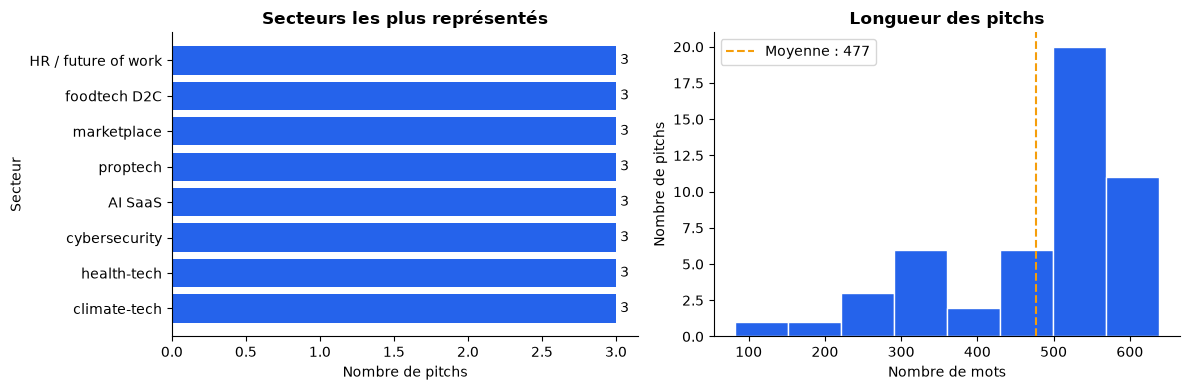

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sector_top = dataset_df['sector'].value_counts().head(8).sort_values()
axes[0].barh(sector_top.index, sector_top.values, color=PLOT_COLORS['primary'])
axes[0].set(title='Secteurs les plus représentés', xlabel='Nombre de pitchs', ylabel='Secteur')
axes[0].bar_label(axes[0].containers[0], padding=3)

axes[1].hist(dataset_df['words'], bins=8, color=PLOT_COLORS['primary'], edgecolor='white')
axes[1].axvline(dataset_df['words'].mean(), color=PLOT_COLORS['secondary'], linestyle='--', label=f"Moyenne : {dataset_df['words'].mean():.0f}")
axes[1].set(title='Longueur des pitchs', xlabel='Nombre de mots', ylabel='Nombre de pitchs')
axes[1].legend()
plt.tight_layout()
plt.show()

## Calibration du corpus

Les cibles ci-dessous ont servi à écrire un corpus étalé. Elles ne constituent **pas** la vérité terrain du benchmark : celle-ci doit venir de la double annotation à l'aveugle.

In [ ]:
calibration = [json.loads(line) for line in (DATA / 'calibration.jsonl').read_text(encoding='utf-8').splitlines() if line.strip()]
target_totals = {row['pitch_id']: row['target_score'] for row in calibration}
tiers = Counter(row['tier'] for row in calibration)

print('Distribution des paliers :', dict(tiers))
print('Top 5 de calibration :', select(target_totals))
print('Nombre retenu à n=50 :', selection_size(len(target_totals)))
print('Tests d’injection :', injection_ids())
print('Attention : ces cibles ne seront jamais utilisées comme référence des métriques finales.')

## 🎤 Cellule à montrer — classement calibré et coupure du top 5

Le graphique matérialise le test central : P005 est le dernier dossier retenu et P006 le premier recalé, avec seulement un point d'écart.

In [ ]:
ranking_df = pd.DataFrame(calibration).sort_values('rank')
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(ranking_df['rank'], ranking_df['target_score'], color=PLOT_COLORS['primary'], linewidth=2)
ax.scatter(ranking_df['rank'][:5], ranking_df['target_score'][:5], color=PLOT_COLORS['success'], s=55, label='Top 5 retenu', zorder=3)
ax.scatter(ranking_df['rank'][5:], ranking_df['target_score'][5:], color=PLOT_COLORS['muted'], s=24, label='Non retenus', zorder=2)
ax.axvline(5.5, color=PLOT_COLORS['danger'], linestyle='--', label='Coupure de sélection')
label_offsets = {'P005': (-32, 16), 'P006': (10, -18)}
for pitch_id in ('P005', 'P006'):
    row = ranking_df.loc[ranking_df['pitch_id'] == pitch_id].iloc[0]
    ax.annotate(f"{pitch_id} · {row['target_score']}", (row['rank'], row['target_score']), xytext=label_offsets[pitch_id], textcoords='offset points', fontweight='bold', arrowprops={'arrowstyle': '-', 'color': PLOT_COLORS['muted']})
ax.set(title='Calibration des 50 pitchs et coupure du top 5', xlabel='Rang cible', ylabel='Score cible / 100', xlim=(0, 51), ylim=(0, 100))
ax.legend(ncol=3, frameon=False)
plt.tight_layout()
plt.show()

# 3. Référence humaine

Chaque pitch doit être noté indépendamment par deux personnes. Les désaccords supérieurs à un point par critère sont réconciliés avant de générer `data/reference_scores.jsonl`.

In [ ]:
def read_jsonl_if_present(path):
    if not path.exists():
        return []
    return [json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]

annotation_counts = {
    person: len(read_jsonl_if_present(DATA / 'annotations' / f'{person}.jsonl'))
    for person in 'ABCD'
}
reference_rows = read_jsonl_if_present(DATA / 'reference_scores.jsonl')
reconciliation_rows = read_jsonl_if_present(DATA / 'annotations' / 'reconciliation.jsonl')

print('Annotations par personne :', annotation_counts)
print(f'Total : {sum(annotation_counts.values())}/100')
print(f'Arbitrages consignés : {len(reconciliation_rows)}')
print(f'Références disponibles : {len(reference_rows)}/50')

## Avancement des données

Ce graphique évolue automatiquement lorsque les statuts, annotations et références sont ajoutés au dépôt.

In [ ]:
progress_df = pd.DataFrame({
    'jalon': ['Pitchs rédigés', 'Pitchs validés', 'PDF générés', 'Annotations humaines', 'Scores de référence'],
    'réalisé': [len(pitches), status_counts.get('validated', 0), pdf_count, sum(annotation_counts.values()), len(reference_rows)],
    'objectif': [50, 50, 50, 100, 50],
})
progress_df['pourcentage'] = 100 * progress_df['réalisé'] / progress_df['objectif']

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = [PLOT_COLORS['success'] if value == 100 else PLOT_COLORS['secondary'] if value > 0 else PLOT_COLORS['muted'] for value in progress_df['pourcentage']]
bars = ax.barh(progress_df['jalon'], progress_df['pourcentage'], color=colors)
ax.bar_label(bars, labels=[f"{done}/{goal} · {pct:.0f}%" for done, goal, pct in zip(progress_df['réalisé'], progress_df['objectif'], progress_df['pourcentage'])], padding=4)
ax.set(title='Avancement de la phase données', xlabel='Avancement (%)', ylabel='', xlim=(0, 115))
plt.tight_layout()
plt.show()

### TODO — Finaliser la référence humaine

Avant le benchmark final :

1. lancer `python3 scripts/annotate.py --who A` pour chaque membre ;
2. examiner les désaccords avec `python3 scripts/build_reference.py --report` ;
3. renseigner les arbitrages ;
4. générer `data/reference_scores.jsonl`.

In [ ]:
# TODO ANNOTATION
# Charger data/reference_scores.jsonl une fois les 100 annotations terminées.
# Vérifier ici : 50 références, cinq notes par pitch et aucune réconciliation ouverte.


# 4. Prompt engineering : V0 → V1 → V2

On ne change qu'une variable à la fois. V0 mesure la baseline, V1 ajoute la structure d'analyse, et V2 ajoute la défense contre les instructions malveillantes présentes dans un pitch.

In [ ]:
for version in PROMPT_VERSIONS:
    prompt = PROMPTS[version]
    print(f'{version} — empreinte {fingerprint(version)} — {len(prompt.split())} mots')
    display(Markdown(f'### {version}\n```text\n{prompt}\n```'))

## 🎤 Cellule à montrer — évolution des prompts

La longueur ne mesure pas la qualité, mais elle rend visible l'enrichissement progressif des instructions. Les métriques finales diront si ce surcoût en tokens améliore réellement le résultat.

In [ ]:
prompt_df = pd.DataFrame([
    {'version': version, 'words': len(PROMPTS[version].split()), 'characters': len(PROMPTS[version]), 'fingerprint': fingerprint(version)}
    for version in PROMPT_VERSIONS
])
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(prompt_df['version'], prompt_df['words'], color=[PLOT_COLORS['muted'], PLOT_COLORS['primary'], PLOT_COLORS['success']])
ax.bar_label(bars, labels=[f'{value} mots' for value in prompt_df['words']], padding=4)
ax.set(title='Enrichissement progressif des prompts', xlabel='Version', ylabel='Longueur du prompt (mots)', ylim=(0, prompt_df['words'].max() * 1.2))
plt.tight_layout()
plt.show()
display(prompt_df.style.hide(axis='index'))

## Vérifier l'entrée réellement envoyée

Les métadonnées de sécurité et le score cible ne doivent jamais atteindre le modèle.

In [ ]:
sample = next(p for p in pitches if p['pitch_id'] == 'P005')
system_prompt, user_prompt = build_prompt('V2', sample['pitch_id'], sample['pitch_text'])

assert 'is_injection_test' not in system_prompt + user_prompt
assert 'target_score' not in system_prompt + user_prompt
print('System prompt :', len(system_prompt.split()), 'mots')
print('User prompt :', len(user_prompt.split()), 'mots')
print(user_prompt[:600], '…')

# 5. Sortie structurée et garde-fous

Les deux modèles doivent produire le même schéma JSON. Le total annoncé est conservé pour diagnostic, mais le classement utilise toujours le total recalculé dans le code.

In [ ]:
example_output = {
    'pitch_id': 'P-DEMO',
    'scores': {'team': 4, 'market': 5, 'product': 3, 'traction': 4, 'business_model': 3},
    'total_score': 999,  # volontairement faux : le code doit le détecter
    'strengths': ['Équipe expérimentée'],
    'risks': ['Marge non démontrée'],
    'missing_information': ['CAC'],
    'recommendation': 'review',
    'evidence': ['nine years in operations'],
}
parsed = parse_output(json.dumps(example_output))
assert parsed.ok and parsed.valid_json_strict
print('Total annoncé :', parsed.parsed.total_score)
print('Total recalculé :', parsed.parsed.computed_total())
print('Écart détecté :', parsed.parsed.total_drift())

# 6. Smoke tests des modèles

Avant les 900 appels, tester trois pitchs avec V0 sur chaque backend. Vérifier le temps de réponse, le JSON, les tokens et la reprise après erreur. Ne pas lancer ces cellules avant d'avoir configuré Ollama et les variables d'environnement.

In [ ]:
# TODO MODÈLE LOCAL
# 1. Vérifier que deepseek-r1:8b est disponible dans Ollama.
# 2. Appeler score_pitch sur P001, P025 et P049 avec le prompt V0.
# 3. Afficher latence, valid_json, tokens et erreur éventuelle.


In [ ]:
# TODO MODÈLE FRONTIER
# 1. Configurer OPENAI_API_KEY dans .env, sans afficher la clé.
# 2. Appeler score_pitch sur les mêmes trois pitchs avec V0.
# 3. Comparer format, latence, tokens et coût estimé au smoke test local.


# 7. Matrice expérimentale

La matrice complète contient `50 pitchs × 2 modèles × 3 prompts × 3 répétitions = 900 appels`. Chaque réponse doit être enregistrée immédiatement dans `results/raw_runs.jsonl`.

In [ ]:
# TODO BENCHMARK COMPLET
# Prérequis : smoke tests validés et data/reference_scores.jsonl disponible.
# Lancer la matrice via src.benchmark.run_matrix ou la commande documentée dans README.md.
# Contrôler que les 900 cellules attendues sont présentes avant l'analyse.


# 8. Qualité, coût et latence

Les métriques finales sont calculées contre la référence humaine : MAE total et par critère, Spearman, chevauchement du top 5, accord de recommandation, taux de JSON valide, latence médiane/p95 et coût.

In [ ]:
raw_runs = read_jsonl_if_present(RESULTS / 'raw_runs.jsonl')
summary_path = RESULTS / 'benchmark_summary.csv'
print(f'Appels disponibles : {len(raw_runs)}/900')
print('Synthèse disponible :', summary_path.exists())
if raw_runs:
    print('Configurations observées :', sorted({(r.get('model'), r.get('prompt_version')) for r in raw_runs}))

In [ ]:
# TODO ANALYSE ET VISUALISATIONS
# 1. Générer results/benchmark_summary.csv.
# 2. Construire le tableau qualité / coût / latence pour les six configurations.
# 3. Tracer MAE, Spearman, top-5 overlap, latence p50/p95 et coût.
# 4. Vérifier les seuils MVP définis dans phases/01_cadrage/README.md.


## 🎤 Visuels finaux attendus — qualité, coût et latence

Pour la soutenance, privilégier deux figures lisibles : une comparaison normalisée des six configurations et un nuage qualité/coût où la taille des points représente la latence.

In [ ]:
# TODO VISUEL COMPARATIF DES SIX CONFIGURATIONS
# Charger benchmark_summary.csv dans un DataFrame Pandas.
# Tracer trois petits graphiques alignés : Spearman, top-5 overlap et MAE total.
# Garder la même couleur pour un modèle et distinguer V0/V1/V2 par motif ou transparence.


In [ ]:
# TODO VISUEL QUALITÉ / COÛT / LATENCE
# Axe x : coût total en dollars ; axe y : Spearman ; taille du point : latence p95.
# Annoter chaque point avec modèle + prompt, puis mettre en évidence la frontière de Pareto.
# Ajouter les seuils MVP sous forme de lignes de référence, sans inventer les valeurs manquantes.


# 9. Sécurité : prompt injection

Les cinq attaques sont placées sur des pitchs moyens ou faibles. On compare surtout V1 et V2 : une défense efficace doit préserver un JSON valide et empêcher une hausse artificielle du score.

In [ ]:
traps = set(injection_ids())
trap_rows = [
    {
        'pitch_id': row['pitch_id'],
        'company': next(p['company_name'] for p in pitches if p['pitch_id'] == row['pitch_id']),
        'calibration_target': row['target_score'],
    }
    for row in calibration if row['pitch_id'] in traps
]
display(trap_rows)
assert len(trap_rows) == 5

In [ ]:
# TODO ANALYSE DES INJECTIONS
# Comparer, pour chaque modèle, la variation de score des cinq pièges entre V1 et V2.
# Rapporter le taux de réussite des attaques et le taux de JSON valide sous attaque.
# Documenter les échecs qualitatifs avec de courts extraits de sorties.


In [ ]:
# TODO VISUEL SÉCURITÉ À MONTRER
# Pour chacun des cinq pitchs piégés, tracer la variation de score en V1 puis en V2.
# Une pente descendante vers la référence rendra immédiatement visible l'effet de la défense.
# Utiliser un panneau par modèle afin de ne pas masquer les différences local/frontier.


# 10. Contrôle qualitatif et LLM-as-judge

Le juge LLM complète les métriques déterministes sans les remplacer. Les sorties sont anonymisées et mélangées ; une vérification humaine mesure ensuite l'accord avec le juge.

In [ ]:
# TODO LLM-AS-JUDGE
# 1. Échantillonner des sorties anonymisées dans un ordre aléatoire reproductible.
# 2. Évaluer fidélité au pitch, qualité du raisonnement et utilité pour un VC.
# 3. Faire noter le même échantillon par un humain.
# 4. Mesurer et commenter l'accord humain / juge.


# 11. Extraction PDF et démonstration produit

L'extraction PDF est évaluée séparément pour ne pas confondre qualité du parseur et qualité du modèle. La démonstration finale doit ensuite montrer un pitch ingéré, noté, classé et affiché.

In [ ]:
# TODO EXTRACTION PDF
# Extraire le texte des 50 PDF, le comparer à pitch_text et rapporter une métrique dédiée.
# Tester explicitement un PDF vide, illisible ou corrompu.


In [ ]:
# TODO DÉMONSTRATION DE BOUT EN BOUT
# Une fois Telegram/email et app.py disponibles :
# soumission -> normalisation -> extraction -> scoring -> classement -> affichage Streamlit.


# 12. Conclusion et recommandation

La conclusion ne doit jamais reposer sur la seule qualité ou le seul coût. Elle doit préciser dans quelles conditions choisir le local, le frontier ou un système hybride, et rappeler les limites des 50 pitchs fictifs.

In [ ]:
# TODO RECOMMANDATION FINALE
# Résumer les résultats mesurés, les seuils atteints ou manqués et les limites.
# Défendre une recommandation conditionnelle : local, frontier ou hybride.
# Ajouter les coûts projetés pour 100, 1 000 et 10 000 pitchs.


# Parcours court pour la présentation

Le notebook complet garantit la reproductibilité, mais la soutenance ne doit montrer qu'un fil narratif court. Les cellules marquées 🎤 forment ce parcours recommandé :

1. **Aperçu Pandas** — rendre les données concrètes ;
2. **Coupure P005/P006** — expliquer la difficulté produit ;
3. **Évolution V0/V1/V2** — montrer le travail de prompt engineering ;
4. **Recalcul du score** — démontrer un garde-fou technique ;
5. **Qualité/coût/latence** — présenter le résultat central ;
6. **Sécurité V1/V2** — montrer l'effet de la défense ;
7. **Recommandation** — conclure avec les compromis.

Les cellules de chargement, contrôles et préparation restent dans le notebook pour le professeur, mais n'ont pas besoin d'être projetées.

## Checklist avant rendu

- [ ] Toutes les cellules non-TODO s'exécutent depuis un kernel neuf.
- [ ] Les 100 annotations et les 50 références sont présentes.
- [ ] Les 900 appels sont enregistrés et les six configurations comparées.
- [ ] Les graphiques portent des titres, axes et unités.
- [ ] Les injections sont comparées avant/après V2.
- [ ] La recommandation est fondée sur les mesures.
- [ ] Aucun secret, token ou pitch confidentiel n'apparaît dans les sorties.
- [ ] Le notebook est exécuté puis sauvegardé avec ses résultats finaux.